#機械学習の勉強

In [3]:
import pandas as pd
df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\cinema.csv')
df.head(3)

,cinema_id,SNS1,SNS2,actor,original,sales
0,1375,291.0,1044,8808.994029,0,9731
1,1000,363.0,568,10290.709370,1,10210
2,1390,158.0,431,6340.388534,1,8227


In [4]:
df.isnull().any(axis=0)

cinema_id    False
SNS1          True
SNS2         False
actor         True
original     False
sales        False
dtype: bool

In [5]:
df2=df.fillna(df.mean())
df2.isnull().any(axis=0)

cinema_id    False
SNS1         False
SNS2         False
actor        False
original     False
sales        False
dtype: bool

<Axes: xlabel='SNS2', ylabel='sales'>

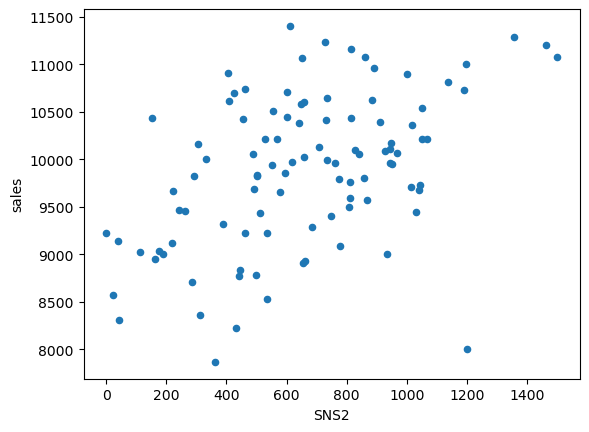

In [6]:
df2.plot(kind='scatter',x='SNS2',y='sales')

<Axes: xlabel='original', ylabel='sales'>

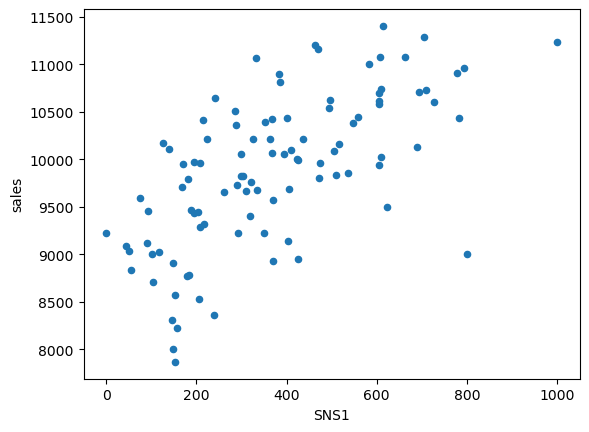

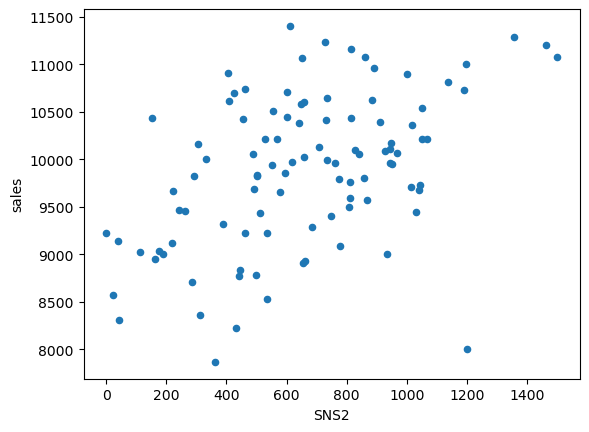

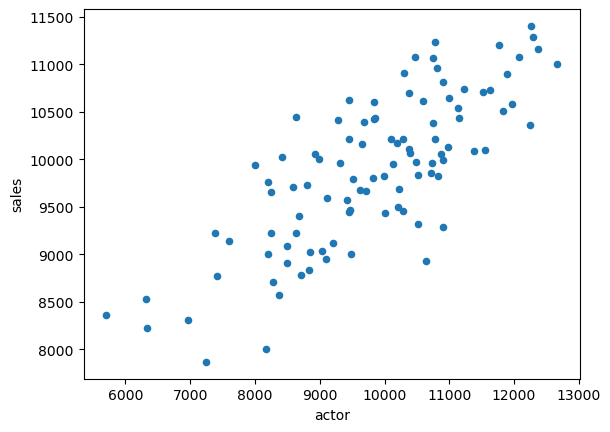

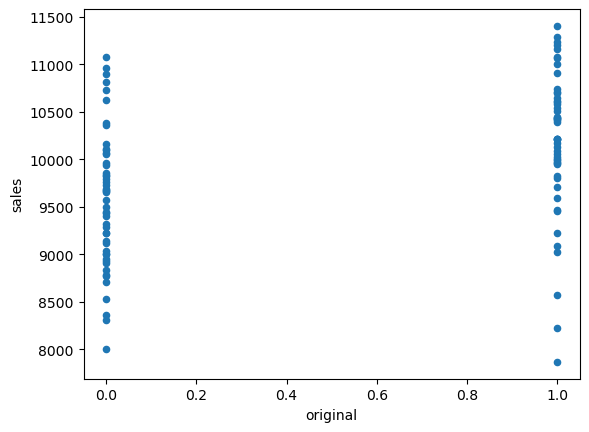

In [7]:
df2.plot(kind='scatter',x='SNS1',y='sales')
df2.plot(kind='scatter',x='SNS2',y='sales')
df2.plot(kind='scatter',x='actor',y='sales')
df2.plot(kind='scatter',x='original',y='sales')

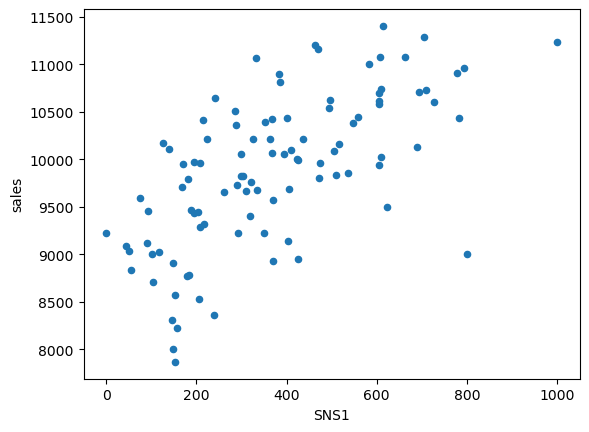

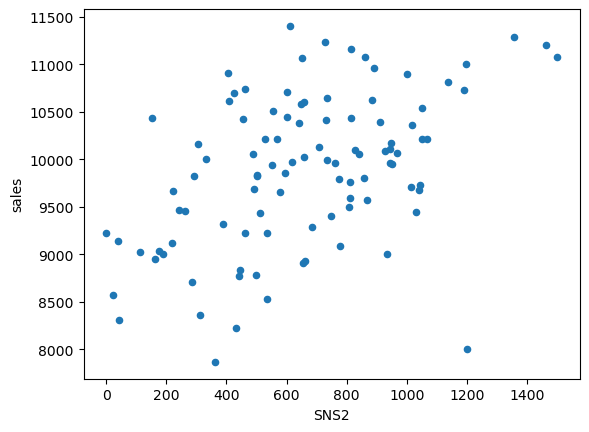

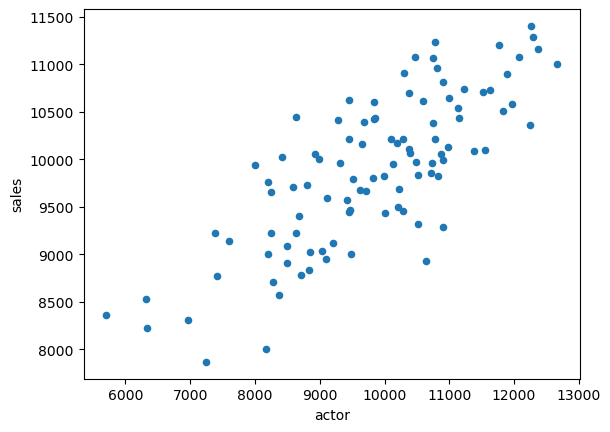

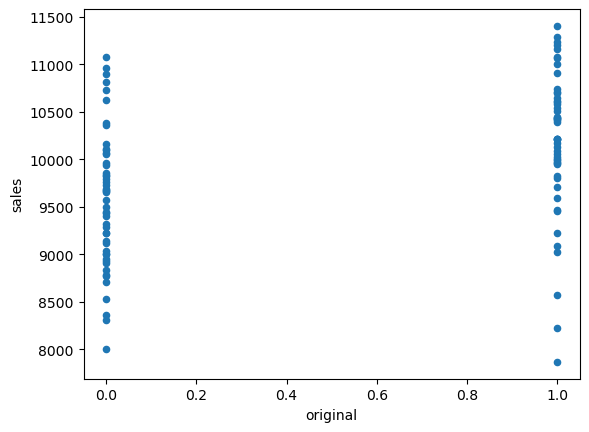

In [8]:
for name in df2.columns:
    if name=='cinema_id'or name=='sales':
        continue
    df2.plot(kind='scatter',x=name,y='sales')

In [9]:
test=pd.DataFrame(
{'Acolumn':[1,2,3],
 'Bcolumn':[4,5,6] 
}
)

In [10]:
test[test['Acolumn']<2]

,Acolumn,Bcolumn
0,1,4


In [11]:
test['Acolumn']<2

0     True
1    False
2    False
Name: Acolumn, dtype: bool

In [12]:
df[(df['SNS2']>1000)&(df['sales']<8500)]


,cinema_id,SNS1,SNS2,actor,original,sales
30,1855,149.0,1200,8173.096892,0,8000


In [13]:
no=df2[(df2['SNS2']>1000)&(df2['sales']<8500)].index
no

Index([30], dtype='int64')

In [14]:
test.drop(0,axis=0)

,Acolumn,Bcolumn
1,2,5
2,3,6


In [15]:
test.drop('Bcolumn',axis=1)

,Acolumn
0,1
1,2
2,3


In [16]:
df3=df2.drop(no,axis=0)
df3.shape

(99, 6)

In [17]:
print(no)

Index([30], dtype='int64')


In [18]:
x=df3[['SNS1','SNS2','actor','original']]
t=df3['sales']

In [19]:
df3.loc[2,'SNS1']

np.float64(158.0)

In [20]:
index=[2,4,6]
col=['SNS1','actor']
df3.loc[index,col]

,SNS1,actor
2,158.0,6340.388534
4,209.0,10908.539550
6,153.0,7237.639848


In [24]:
ex_col=df3.loc[0:99,:'actor']
print(ex_col)

    cinema_id   SNS1  SNS2         actor
0        1375  291.0  1044   8808.994029
1        1000  363.0   568  10290.709370
2        1390  158.0   431   6340.388534
3        1499  261.0   578   8250.485081
4        1164  209.0   683  10908.539550
..        ...    ...   ...           ...
95       1260  494.0  1050  11137.482810
96       1283  505.0   928  11376.038540
97       1861  368.0   966  10393.252480
98       1006  326.0  1068   9454.019853
99       1764  402.0   153  11144.482970

[99 rows x 4 columns]


In [23]:
sample=[10,20,30,40]
display(sample[1:3])

[20, 30]

In [25]:
x=df3.loc[:,'SNS1':'original']
t=df3['sales']

In [26]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,t,test_size=0.2,random_state=0)

In [27]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [28]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
new_data=[
    [150,700,300,0]
]
new=pd.DataFrame(new_data,columns=x_train.columns)
model.predict(new)

array([6874.109753])

In [32]:
from sklearn.metrics import mean_absolute_error
pred=model.predict(x_test)
mean_absolute_error(y_pred=pred,y_true=y_test)

277.1223696408627

In [33]:
model.score(x_test,y_test)   #R値の計算

0.7903881596570088

In [34]:
import pickle
with open('cinema.pkl','wb') as f:
    pickle.dump(model,f)

In [ ]:
print(model.coef_)    #係数
print(model.intercept_)    #切片

[  1.07645622   0.53400191   0.28473752 213.95584503]
6253.418729438707


In [37]:
tmp=pd.DataFrame(model.coef_)
tmp.index=x_train.columns
print(tmp)

                   0
SNS1        1.076456
SNS2        0.534002
actor       0.284738
original  213.955845
